# <span style="color:darkblue"> Lecture 12b - Random Assignment </span>

<font size = "5">



# <span style="color:darkblue"> I. Import Libraries and Data </span>


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
carfeatures = pd.read_csv("data_raw/features.csv")

# <span style="color:darkblue"> II. Random Assignment </span>

<font size = "5">

Random assignment is crucial for scientific progress ...

- The basis for medical trials
- Also used in engineering, the natural sciences and <br>
  social sciences (economics, political science, etc.)


In [3]:
# "list_status" is a list with "treatment/control" arms
# "prop_status" is the proportion in the treatment and control arms
# "size_dataset" is how many rows are contained

list_status  = ["Treatment","Control"]
prop_status  = [0.4,0.6]
size_dataset = len(carfeatures)

<font size = "5">
Random assignment


In [4]:
# The "np.random.choice" will create a vector with the status
# We will save this to a column in "carfeatures"
# Note: (i) We can always split the arguments of a function in multiple lines
#           to make it easier to read

carfeatures["status"] = np.random.choice(list_status,
                                         size = size_dataset,
                                         p = prop_status)

display(carfeatures)

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle_id,status
0,18.0,8,307,130,3504,12.0,C-1689780,Treatment
1,15.0,8,350,165,3693,11.5,B-1689791,Treatment
2,18.0,8,318,150,3436,11.0,P-1689802,Control
3,16.0,8,304,150,3433,12.0,A-1689813,Control
4,17.0,8,302,140,3449,10.5,F-1689824,Control
...,...,...,...,...,...,...,...,...
393,27.0,4,140,86,2790,15.6,F-1694103,Control
394,44.0,4,97,52,2130,24.6,V-1694114,Control
395,32.0,4,135,84,2295,11.6,D-1694125,Control
396,28.0,4,120,79,2625,18.6,F-1694136,Control


<font size = "5">

Compute frequencies by status

In [5]:
# The command "pd.crosstab" computes frequencies
# If we add the option "normalize" it will compute proportions
# Note: The default assignment is done randomly without replacement
#       which means that the proportions are approximately the same   
#       (but not equal) to "prop_status"

frequency_table   = pd.crosstab(index = carfeatures["status"], columns = "Frequency")
proportions_table = pd.crosstab(index = carfeatures["status"],
                                columns = "Frequency",
                                normalize = True)

display(frequency_table)
display(proportions_table)


col_0,Frequency
status,
Control,251
Treatment,147


col_0,Frequency
status,
Control,0.630653
Treatment,0.369347


<font size = "5">

Query with string conditions

In [6]:
# When you have queries for text variables, it's important
# to use outer ' ' single quotations
# and inner double quotations.

data_treated = carfeatures.query('status == "Treatment" ')
data_control = carfeatures.query('status == "Control" ')

<font size = "5">

Treated/control should be similar

- This is the key principle of random assignment
- We can check the summary statistics

In [7]:
# The count is different because we assigned different proportions
# All other sumary statistics are approximately the same
# They are not identical because the assignment is random

display(data_treated.describe())
display(data_control.describe())

,mpg,cylinders,displacement,weight,acceleration
count,147.000000,147.000000,147.000000,147.000000,147.000000
mean,23.793197,5.374150,187.462585,2925.673469,15.744898
std,8.092163,1.688847,102.699140,840.868380,2.827923
min,9.000000,3.000000,70.000000,1760.000000,8.500000
25%,18.000000,4.000000,98.000000,2188.500000,14.000000
50%,23.000000,4.000000,140.000000,2720.000000,15.500000
75%,29.700000,6.000000,258.000000,3577.500000,17.350000
max,46.600000,8.000000,455.000000,4997.000000,23.700000


,mpg,cylinders,displacement,weight,acceleration
count,251.000000,251.000000,251.000000,251.000000,251.000000
mean,23.351394,5.501992,196.920319,2996.633466,15.464542
std,7.661318,1.709677,105.223503,850.899435,2.716067
min,10.000000,3.000000,68.000000,1613.000000,8.000000
25%,17.250000,4.000000,107.000000,2250.500000,13.650000
50%,22.300000,4.000000,151.000000,2890.000000,15.500000
75%,28.200000,8.000000,302.000000,3607.000000,17.000000
max,44.600000,8.000000,455.000000,5140.000000,24.800000


<font size = "5">

Exercises:

Import the dataset "data_quiz/fifa23_players_basic.csv"

- It's a dataset on professional soccer players
- Rows correspond to players (18,539)
- Columns contain attributes of players (32)
- Try to view the dataset before starting

<font size = "5">

Try it yourself!

<font size = "3">

- Create ``` list_status = [0,1]```
- Create ``` list_prob = [0.5, 0.5]```
- Create a new variable $n$ with the number of rows of the dataset
- Use 
```python
    np.random.choice(list_status,
                     size = n,
                     p = list_prob)
```
$\qquad$ to create a new column called "status" <br>
$\qquad$ which randomly assigns each row to "0" or "1" <br>
$\qquad$ with equal probability
- Use .query() to subset all observations with status == 0.<br>
store it in a new dataset called "data0"
- Use .query() to subset all observations with status == 1.<br>
store it in a new dataset called "data1"



In [5]:
# Write your own code
soccer = pd.read_csv("data_raw/fifa23_players_basic.csv")

n = len(soccer)

list_status = [0, 1]
list_prob = [0.5, 0.5]
status = np.random.choice(list_status,
                     size = n,
                     p = list_prob)

data0 = soccer.query("@status == 0")
data1 = soccer.query("@status == 1")

<font size = "5">

Try it yourself!

<font size = "3">

- This question requires the two datasets you created in the previous question
- Display the distribution of "Age" for "data0" and "data1"
- Use the "alpha" option to make the graphs semitransparent
- You will need to add a legend, label the axes, and the title

Note: The goal of this question is to illustrate that random <br>
assignment produces very similar distributions between two groups

<function matplotlib.pyplot.show(close=None, block=None)>

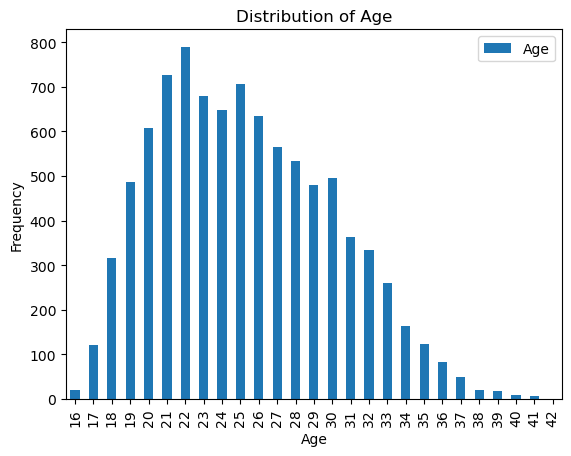

In [9]:
# Write your own code

data0["Age"].value_counts().sort_index().plot(kind = "bar")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.legend(["Age"]) 
plt.show



# <span style="color:darkblue"> III. Further information </span>

<font size = "5">

https://discovery.cs.illinois.edu/learn/Basics-of-Data-Science-with-Python/Experimental-Design-and-Blocking/